In [42]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/crop-yield-and-environmental-factors-2014-2023/crop_yield_dataset.csv


In [43]:
import pandas as pd
data=pd.read_csv("/kaggle/input/crop-yield-and-environmental-factors-2014-2023/crop_yield_dataset.csv")
print(data.head())
print(len(data))

         Date Crop_Type Soil_Type  Soil_pH  Temperature   Humidity  \
0  2014-01-01     Wheat     Peaty     5.50     9.440599  80.000000   
1  2014-01-01      Corn     Loamy     6.50    20.052576  79.947424   
2  2014-01-01      Rice     Peaty     5.50    12.143099  80.000000   
3  2014-01-01    Barley     Sandy     6.75    19.751848  80.000000   
4  2014-01-01   Soybean     Peaty     5.50    16.110395  80.000000   

   Wind_Speed     N     P     K  Crop_Yield  Soil_Quality  
0   10.956707  60.5  45.0  31.5    0.000000     22.833333  
1    8.591577  84.0  66.0  50.0  104.871310     66.666667  
2    7.227751  71.5  54.0  38.5    0.000000     27.333333  
3    2.682683  50.0  40.0  30.0   58.939796     35.000000  
4    7.696070  49.5  45.0  38.5   32.970413     22.166667  
36520


In [44]:
data=data[data['Crop_Yield']!=0.0]
print(len(data))
print(data.head())

25495
         Date Crop_Type Soil_Type  Soil_pH  Temperature   Humidity  \
1  2014-01-01      Corn     Loamy     6.50    20.052576  79.947424   
3  2014-01-01    Barley     Sandy     6.75    19.751848  80.000000   
4  2014-01-01   Soybean     Peaty     5.50    16.110395  80.000000   
5  2014-01-01    Cotton     Sandy     6.75    14.826739  80.000000   
7  2014-01-01    Tomato      Clay     6.25    18.323272  80.000000   

   Wind_Speed     N     P     K  Crop_Yield  Soil_Quality  
1    8.591577  84.0  66.0  50.0  104.871310     66.666667  
3    2.682683  50.0  40.0  30.0   58.939796     35.000000  
4    7.696070  49.5  45.0  38.5   32.970413     22.166667  
5   10.366657  55.0  44.0  36.0   29.356115     39.375000  
7    8.198084  60.0  45.0  40.0   22.221375     42.291667  


After dropping columns with crop_yield with 0.0 we get the number of rows from 36520 to 25495

In [45]:
data['Date']=pd.to_datetime(data['Date'],errors='coerce')
print(data.head())

        Date Crop_Type Soil_Type  Soil_pH  Temperature   Humidity  Wind_Speed  \
1 2014-01-01      Corn     Loamy     6.50    20.052576  79.947424    8.591577   
3 2014-01-01    Barley     Sandy     6.75    19.751848  80.000000    2.682683   
4 2014-01-01   Soybean     Peaty     5.50    16.110395  80.000000    7.696070   
5 2014-01-01    Cotton     Sandy     6.75    14.826739  80.000000   10.366657   
7 2014-01-01    Tomato      Clay     6.25    18.323272  80.000000    8.198084   

      N     P     K  Crop_Yield  Soil_Quality  
1  84.0  66.0  50.0  104.871310     66.666667  
3  50.0  40.0  30.0   58.939796     35.000000  
4  49.5  45.0  38.5   32.970413     22.166667  
5  55.0  44.0  36.0   29.356115     39.375000  
7  60.0  45.0  40.0   22.221375     42.291667  


In [46]:
#Drop categorical columns
data = data.select_dtypes(include=['number', 'datetime'])
print(data.head())

        Date  Soil_pH  Temperature   Humidity  Wind_Speed     N     P     K  \
1 2014-01-01     6.50    20.052576  79.947424    8.591577  84.0  66.0  50.0   
3 2014-01-01     6.75    19.751848  80.000000    2.682683  50.0  40.0  30.0   
4 2014-01-01     5.50    16.110395  80.000000    7.696070  49.5  45.0  38.5   
5 2014-01-01     6.75    14.826739  80.000000   10.366657  55.0  44.0  36.0   
7 2014-01-01     6.25    18.323272  80.000000    8.198084  60.0  45.0  40.0   

   Crop_Yield  Soil_Quality  
1  104.871310     66.666667  
3   58.939796     35.000000  
4   32.970413     22.166667  
5   29.356115     39.375000  
7   22.221375     42.291667  


In [47]:
data = data.set_index('Date')
print(data.head())

            Soil_pH  Temperature   Humidity  Wind_Speed     N     P     K  \
Date                                                                        
2014-01-01     6.50    20.052576  79.947424    8.591577  84.0  66.0  50.0   
2014-01-01     6.75    19.751848  80.000000    2.682683  50.0  40.0  30.0   
2014-01-01     5.50    16.110395  80.000000    7.696070  49.5  45.0  38.5   
2014-01-01     6.75    14.826739  80.000000   10.366657  55.0  44.0  36.0   
2014-01-01     6.25    18.323272  80.000000    8.198084  60.0  45.0  40.0   

            Crop_Yield  Soil_Quality  
Date                                  
2014-01-01  104.871310     66.666667  
2014-01-01   58.939796     35.000000  
2014-01-01   32.970413     22.166667  
2014-01-01   29.356115     39.375000  
2014-01-01   22.221375     42.291667  


In [48]:
average_daily=data.resample('D').mean()

In [49]:
average_daily

,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
Date,,,,,,,,,
2014-01-01,6.250000,17.832341,79.992489,7.649061,61.285714,50.142857,40.142857,52.962570,41.714286
2014-01-02,6.928571,17.403738,79.997477,9.731096,67.285714,54.500000,43.785714,49.481053,31.964286
2014-01-03,6.250000,17.710699,78.611669,12.161914,60.785714,49.571429,40.142857,31.582386,40.601190
2014-01-04,7.125000,17.068594,79.349411,9.476664,69.375000,56.000000,44.937500,35.247034,38.703125
2014-01-05,6.375000,15.439732,80.000000,10.793227,68.062500,54.562500,43.125000,32.578187,48.994792
...,...,...,...,...,...,...,...,...,...
2023-12-27,6.406250,18.765488,79.418663,10.391741,63.687500,51.937500,41.125000,45.000561,27.786458
2023-12-28,6.583333,15.818711,79.517023,11.417404,66.000000,54.166667,42.833333,36.566595,41.680556
2023-12-29,6.843750,17.750068,79.094460,9.926405,66.062500,53.687500,42.375000,42.949637,39.281250


We had done the average of the numerical columns for each day by using resample and 'D' for daily basis

Now we should perform decomposition to know about the proprties of the dataset. We used STL decomposition used for only additive data 

In [50]:
import pandas as pd
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

# --- Choose the time series column ---
series = average_daily['Crop_Yield']  


In [51]:
# ---  Perform STL decomposition ---
stl = STL(series, period=5)   # adjust period as per your data frequency
result = stl.fit()

In [52]:
# ---  Extract components ---
observed = series
trend = result.trend
seasonal = result.seasonal
residual = result.resid

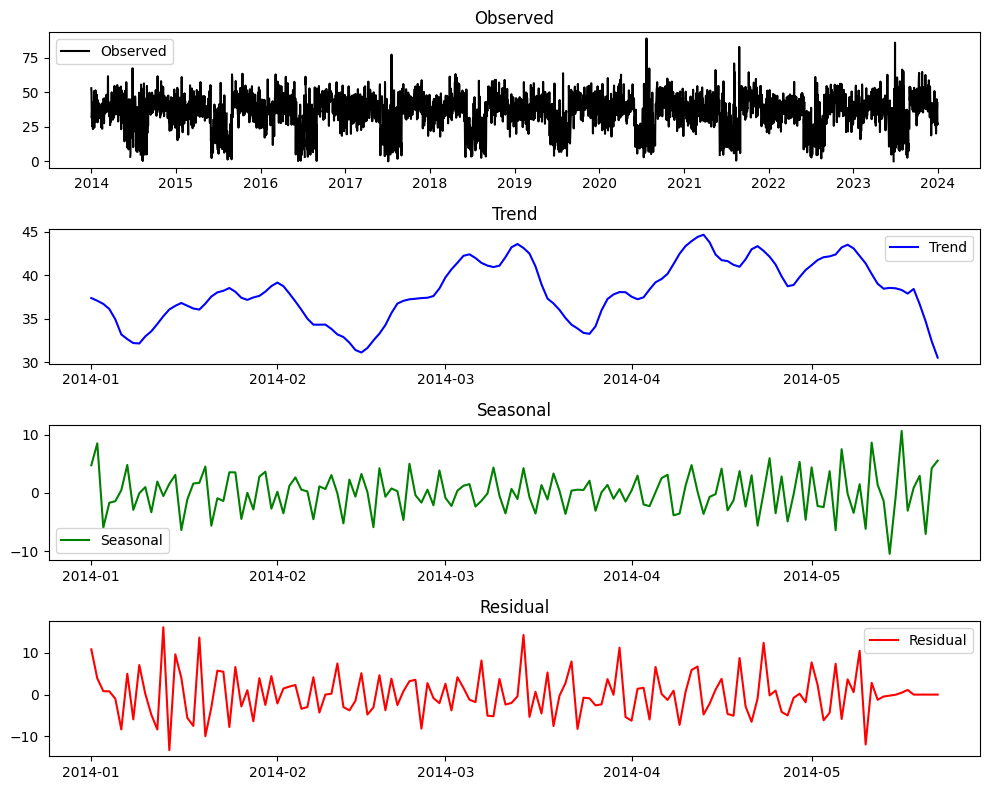

In [ ]:
# ---  Plot each component separately ---
plt.figure(figsize=(10, 8))

plt.subplot(4, 1, 1)
plt.plot(observed, label='Observed', color='black')
plt.title('Observed')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend', color='blue')
plt.title('Trend')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Seasonal', color='green')
plt.title('Seasonal')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(residual, label='Residual', color='red')
plt.title('Residual')
plt.legend()

plt.tight_layout()
plt.show()

here for weak stationarity we the mean,varaince and auto correlation must be constant 

By the images we can say that data is not stationary 

Let us do ADF(Augmented Dicky Fuller Test)

In [ ]:
#ADF Test
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(average_daily['Crop_Yield'].dropna())
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")


Here clearly p-value is leass than significance 0.05 and the ADF statistic value is negative 
Hence the dataset is stationary

In [ ]:
print(f" Lags Used          : {adf_result[2]}")
print(f" Observations Used  : {adf_result[3]}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value}")
print(f"IC Best (AIC)        : {adf_result[5]}")


In [ ]:
from statsmodels.tsa.stattools import kpss
kpss_result = kpss(average_daily['Crop_Yield'].dropna(), regression='ct')

In [ ]:
# Extract results
print("KPSS Test Results")
print(f"KPSS Statistic       : {kpss_result[0]}")
print(f"p-value              : {kpss_result[1]}")
print(f"Lags Used            : {kpss_result[2]}")
print("Critical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value}")


p-value is greater than 0.05 Hence accept Null Hypothesis means
The data is stationary also the kpss statistic value is small

Hence Data is stationary 

To know whether the data is strict stationary we have to do KS Test which checks if there is any joint distribution leads to strict stationarity of the data
KS test is about the distribution of the data

The Kolmogorov–Smirnov (KS) test checks whether a sample of data comes from a specific distribution (for example, normal, uniform, etc.).

It is not a stationarity test — instead, it’s about distribution shape.
You can use it, for example, to test if your Crop_Yield values follow a normal distribution (which is often assumed in time series modeling).

In [ ]:
from scipy.stats import kstest, norm
import numpy as np

# Drop missing values
data_series = average_daily['Crop_Yield'].dropna()

# Standardize the data (important for KS test)
standardized_data = (data_series - np.mean(data_series)) / np.std(data_series)

# Run Kolmogorov–Smirnov test against normal distribution
ks_stat, p_value = kstest(standardized_data, 'norm')

print("Kolmogorov–Smirnov Test Results")
print(f"KS Statistic : {ks_stat}")
print(f"p-value       : {p_value}")

here if p-value<0.05 reject Null hypothesis means the data is not normally distributed
clearly the data is not normally distributed

In [ ]:
from prophet import Prophet

In [ ]:
df=average_daily.copy(deep=True)
df

In [ ]:
split_index = int(len(df) * 0.8)
train = df.iloc[:split_index].copy()
test  = df.iloc[split_index:].copy()

In [ ]:
test

In [ ]:
train=train.reset_index().rename(columns={'Date':'ds','Crop_Yield':'y'})

In [ ]:
test  = test.reset_index().rename(columns={'Date': 'ds', 'Crop_Yield': 'y'})

In [ ]:
train.isnull().sum()

In [ ]:
train

In [ ]:
train_raw=train.copy(deep=True)
test_raw=test.copy(deep=True)

In [ ]:
train_raw

In [ ]:
test_raw

In [ ]:
train_raw = train_raw.interpolate().bfill().ffill()
test_raw = test_raw.interpolate().bfill().ffill()

In [ ]:
train_raw.isnull().sum()

In [ ]:
test_raw.isnull().sum()

In [ ]:
model=Prophet()
regressors=['Soil_pH','Temperature','Humidity','Wind_Speed','N','P','K','Soil_Quality']
for reg in regressors:
    model.add_regressor(reg)
model.fit(train_raw)

In [ ]:
model.component_modes

In [ ]:
# Make sure test_raw has all these columns
future = test_raw[['ds', 'Soil_pH', 'Temperature', 'Humidity', 'Wind_Speed', 'N', 'P', 'K', 'Soil_Quality']].copy()

# Predict using the model
forecast = model.predict(future)

In [ ]:
forecast

In [ ]:
# Combine actual vs predicted
results = test_raw[['ds', 'y']].merge(forecast[['ds', 'yhat']], on='ds', how='left')

# Display comparison
print(results.head())

# Evaluate accuracy
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(results['y'], results['yhat'])
mse = mean_squared_error(results['y'], results['yhat'])
r2 = r2_score(results['y'], results['yhat'])

print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"R² Score: {r2:.3f}")

MAE: 4.731	Average absolute difference between actual and predicted yield	Very good — on average, predictions are within ±4.7 units of actual yield
MSE: 38.342	Penalizes larger errors more	Acceptable — lower is better, so doing well
R²: 0.741	Variance explained by the model	🔹 74% accuracy — excellent for time series with multiple regressors

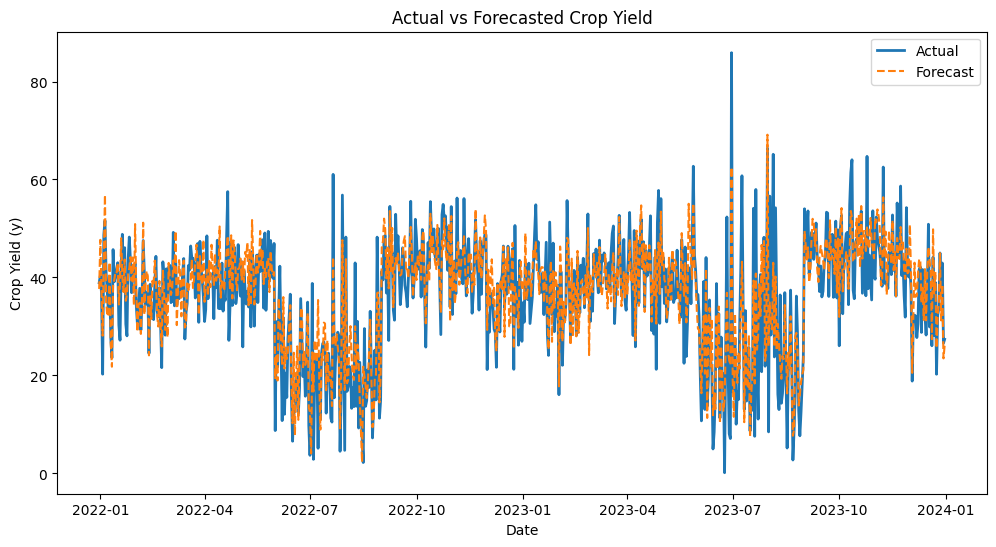

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(results['ds'], results['y'], label='Actual', linewidth=2)
plt.plot(results['ds'], results['yhat'], label='Forecast', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Crop Yield (y)')
plt.title('Actual vs Forecasted Crop Yield')
plt.legend()
plt.show()


In [79]:
# Create 30 future days
future1 = model.make_future_dataframe(periods=30, freq='D')

# Add future regressors (use averages or latest values)
for reg in regressors:
    future1[reg] = train_raw[reg].mean()  # or train_raw[reg].iloc[-1]


In [80]:
future_predictions = model.predict(future1)

In [81]:
future_predictions[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

,ds,yhat,yhat_lower,yhat_upper
2941,2022-01-20,37.043163,29.101235,44.358364
2942,2022-01-21,36.650672,29.048269,43.978940
2943,2022-01-22,36.352073,29.003109,44.098861
2944,2022-01-23,36.687380,29.738821,44.306077
2945,2022-01-24,36.676304,29.729339,44.428697
2946,2022-01-25,36.327467,28.941198,43.506708
2947,2022-01-26,36.946767,29.366959,44.605968
2948,2022-01-27,37.164262,29.718515,45.094407
2949,2022-01-28,36.701883,29.261440,44.453882
2950,2022-01-29,36.329859,28.922218,43.488093


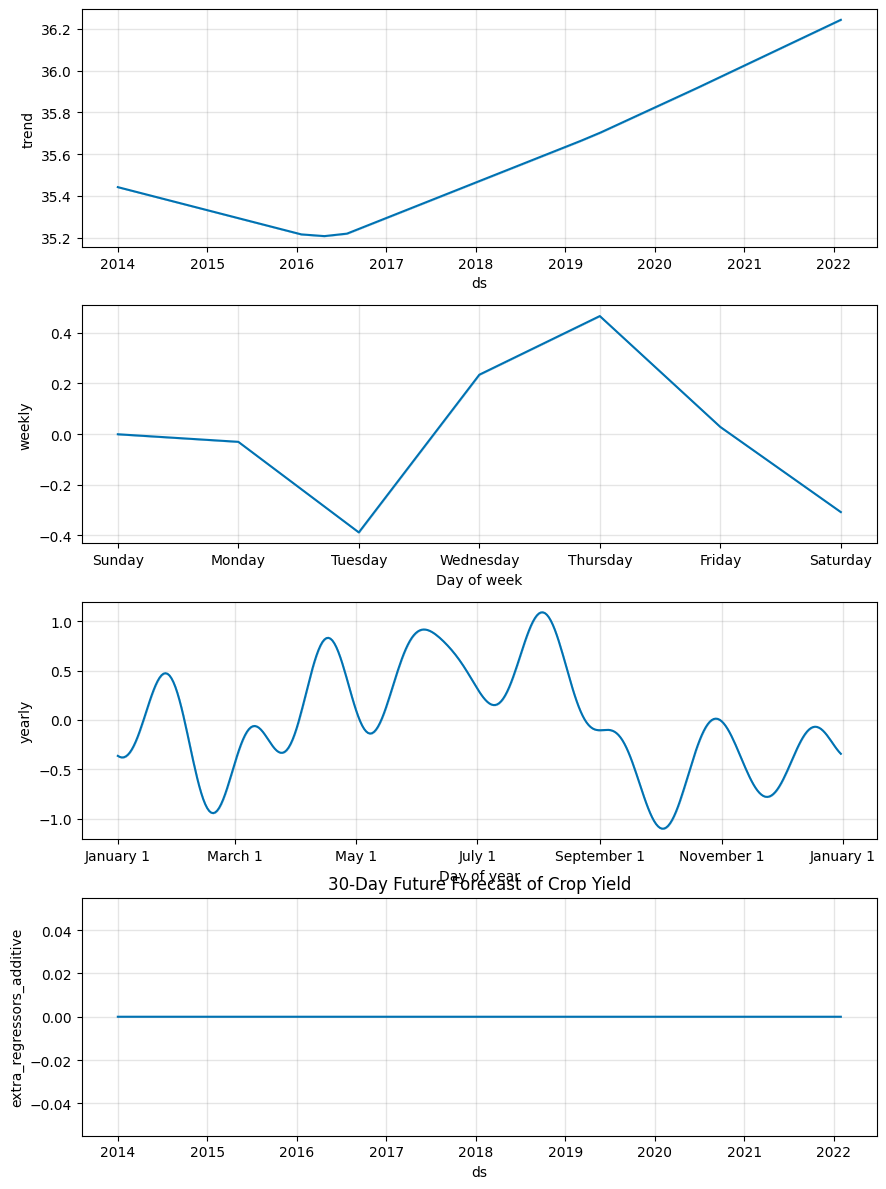

In [82]:
from matplotlib import pyplot as plt
model.plot_components(future_predictions)
plt.title("30-Day Future Forecast of Crop Yield")
plt.show()

In [83]:
import joblib
joblib.dump(model, "prophet_model.pkl")

['prophet_model.pkl']